FEUILLE DE TP 9

---
# Résolution numérique d'une EDO
---

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np                       # pour les numpy array
import matplotlib.pyplot as plt          # librairie graphique

On se propose dans cette partie de mettre en oeuvre quelques schémas numériques **explicites** à **un pas** pour la résolution 
de l'équation différentielle ordinaire : 
\begin{equation}
(EDO)\quad \left\{
\begin{array}{rcl}
x'(t)  &=& f(t, x(t)), \quad t \in ]t_0, t_0 + T[,\\
x(t_0) &=& x^0
\end{array}
\right.
\end{equation}
où  $f \in C^r ([t_0, t_0 + T]\times \mathbb{R}^d; \mathbb{R}^d), x^0 \in \mathbb{R}^d$ et où $T$ est un réel strictement positif et $t_0\in \mathbb{R}$ (les valeurs de $r, t_0, T, d, x^0$ seront précisées dans chaque exercice).

Pour résoudre numériquement ce problème de Cauchy, on se donne un entier $N \in \mathbb{N}^*$, 
et on considère une subdivision uniforme $t_0 < t_1 < \ldots < t_N = (t_0 + T)$ de $[t_0, t_0 + T]$
de pas $\Delta t = \frac{T}{N}$, définie par $t_n = t_0 + n\, \Delta t \quad (0\leq n \leq N)$. 
Puis on construit la suite $(x_n)_{0\leq n\leq N}$ telle que $x_n$ soit une valeur approchée de $x(t_n)$ pour tout $ n \in \{0, \ldots, N\}$, via une schéma numérique à un pas dont une forme générale est donnée par : 

\begin{equation}
(S)\quad \left\{
\begin{array}{rcl}
x_{n+1}  &=& x_n + \Delta t \,\Phi(t_n, x_n, \Delta t), \quad n = 0,\ldots, N-1,\\
x_0 &=& x^0;
\end{array}
\right.
\end{equation}
où $\Phi(\cdot,\cdot,\cdot): \mathbb{R}\times\mathbb{R}^d\times\mathbb{R} \rightarrow \mathbb{R}^d$ est une fonction à trois variables dont on devra péciser l'expression (i.e $\Phi(t, y, \Delta t)$) pour chaque schéma numérique (en fonction de $f $).



---
## Partie I :  Mise en en oeuvre ( cas du shéma d'Euler explicite)
---

On considère dans cette partie, $d = 1$ c'est-à-dire qu'on a une équation scalaire.
On considère le schéma d'Euler explicite :
\begin{equation}
(EE)\quad \left\{
\begin{array}{rcl}
x_{n+1}  &=& x_n + \Delta t \,f(t_n, x_n), \quad n = 0,\ldots, N-1,\\
x_0 &=& x^0.
\end{array}
\right.
\end{equation}

### Question I-1 (Théorique (cours))
>1. Dites en quoi ce schéma est explicite à un pas.
>2. Donnez l'expression la  $\Phi(t,y,\Delta t)$ pour ce schéma.

### Question I-2 : Mise en oeuvre
> 1. Pour mettre en oeuvre ce schéma commencer par fournir une fonction `monPasEuler(f, tn, xn, dt)` 
comme décrit dans la cellule ci-dessous dont le but est de construire la valeur $x_{n+1}$ à partir
de :
>>- $f$ le second membre de l'équation différentielle
>>- l'intant courrant $t_n$ identifié ici par `tn`   
>>- la solution $x_n$ à l'instant $t_n$ identifé ici par `xn`
>>- le pas de la subdivision $\Delta t$, identifié  ici par `dt`.  

In [2]:
def monPasEuler(f, tn, xn, dt):
    """
    fonction qui applique une étape du schéma d'Euler explicite
    Entrées : 
    -------
    - f   : le second membre de l'équation d'éfférentielle
    - tn  : l'instant tn
    - xn  : la solution à l'instant tn
    - dt  : le pas de temps (ou pas de la subdivision)
    Sorties :
    -------
    - tnn : l'instant suivant 
    - xnn : la solution à l'itération suivante
    - dtt : le pas pour l'itération suivante ( dans la plupart des cas ce sera encore dt)
     """
    xnn = xn + dt*f(tn, xn)
    tnn = tn + dt
    dtt = dt
    return tnn, xnn, dtt

> 2. Proposer ensuite une fonction `monEulerExplicite(f, t0, tf, x0, N)`
qui construit la solution approchée du problème de Cauchy en utilisant le schéma d'Euler explicite (EE)
et en faisant des appels à la fonction `monPasEuler` définie précédemment.
>>- Cette fonction prendra en arguments 
>>>- la fonction $f$ second membre de l'équation différentielle,
>>>- l'instant initial $t_0$
>>>- l'instant finale $t_f$ (on rapelle que l'on pourra déduire $T = t_f - t_0$)
>>>- la solution initiale $x_0$
>>>- le nombre $N$ de subdivisions de l'intervalle $[t_0, t_f]$ è considérer
>>- elle retournera 2 `ndarray`:
>>>- la suite $(t_n)_n$ des instants, $n=0, \ldots, N$
>>>- la suite $(x_n)_n$ des solutions approchées aux instants $t_n$.

In [3]:
def monEulerExplicite(f, t0, tf, x0, N):
    """  
    fonction qui applique le schéma d'Euler explicite
    Entrées :
    - f  : le second membre de l'équation différentielle
    - t0 : l'instant initial
    - tf : l'instant final
    - x0 : la condition initiale
    - N  : le nombre de subdivisions de l'intervalle [t0, tf]
    Sorties :
    - tn : la suite des instants
    - xn : la suite des solutions approchées"""
    
    dt = (tf-t0)/N
    tn = [0 for i in range(N)]
    xn = [x0 for i in range(N)]
    for i in range(1, N):
        tn[i], xn[i], dt = monPasEuler(f, tn[i-1], xn[i-1], dt) 

    return tn, xn



### Question I-3 : Validation ( résolution du modèle de **Verhulst**)
On considère le problème suivant ( qui est le modèle de Verhulst de la dynamique des populations)
$$ x'(t) = r \; x(t) \Bigl( 1 - \frac{x(t)}{K} \Bigr), \quad t \in ]0, 5[, \quad x(0) = 0.1 $$
avec $r = 3$ et $K = 2$,
vu dans le `TP1`.  On précise que la solution exacte est 
$
x(t) = \frac{K}{1 + \bigl(\frac{K}{x(0)}-1\bigr) \text{e}^{-rt}}. 
$

Vérifiez votre mise en oeuvre du schéma d'Euler explicite en calculant la solution approchée obtenue par votre fonction  `monEulerExplicite` et  

>1. en représentant sur le même graphique cette solution ainsi que la solution exacte (on prendra `N = 25`),
>2. en imprimant avec la commande `print`, le pas de temps $\Delta t$ et l"erreur en norme infinie entre la solution 
approchée et la solution exacte ($\displaystyle  e_{\Delta t} = \max_{0\leq n \leq N}\| x(t_n) - x_n\|$)



In [4]:
x0, r, K = 0.1, 3, 2
def f(t, y):    
    return r*y*(1-y/K)
    
def x(t):
    return K/(1+(K/x0-1)*np.exp(-r*t))

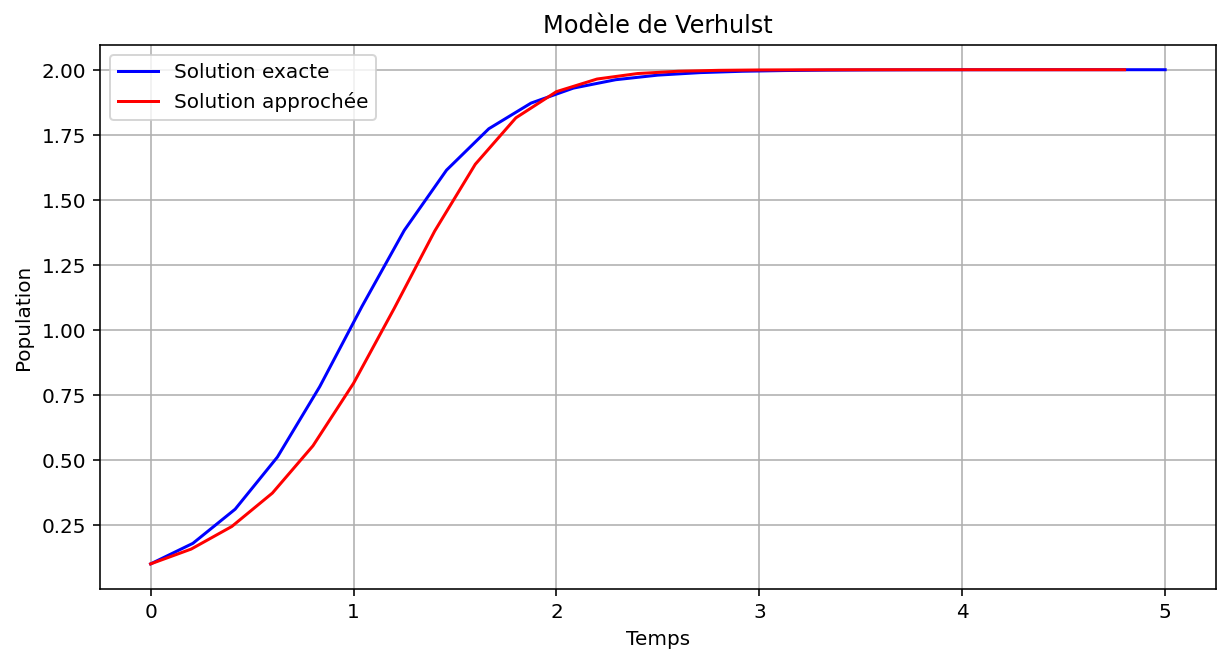

In [6]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)
ax.set_title("Modèle de Verhulst")
ax.set_xlabel("Temps")
ax.set_ylabel("Population")
ax.grid(True)
N = 25
t0, tf = 0, 5
t = np.linspace(t0, tf, N)
y = x(t)
ax.plot(t, y, label="Solution exacte", color='blue')
t, y = monEulerExplicite(f, t0, tf, x0, N)
ax.plot(t, y, label="Solution approchée", color='red')
ax.legend()
plt.show()


---
## Partie II :  Mise en oeuvre ( cas général)
---

### Question II-1 : Généralisation 
Afin de simplifier l'étude d'autres schémas explicites à un pas sans trop dupliquer de codes, 
on conseille de procéder comme dans l'étude des formules d'intégration numériques:

>- Fournissez une fonction générique `monSchemaExplicite(f, t0, tf, x0, N, monPasSchema)`
qui implémente un schéma à un pas explicite. Ses premiers arguments sont les mêmes que ceux de `monEulerExplicite` et son dernier argument identifie le schéma à un pas et aura le même prototype que la fonction  `monPasEuler`.
Ainsi par exemple on pourra réimplémenter la fonction `monEulerExplicite`  à l'aide de cette fonction et de `monPasEuler` comme suit:
>> ```python
def monEulerExplicite(f, t0, tf, x0, N):
    return monSchemaExplicite(f, t0, x0, N, monPasEuler)
```

In [7]:
def monSchemaExplicite(f, t0, tf, x0, N, monPasSchema):
    """ 
    fonction qui applique un schéma explicite
    Entrées :
    - f  : le second membre de l'équation différentielle
    - t0 : l'instant initial
    - tf : l'instant final
    - x0 : la condition initiale
    - N  : le nombre de subdivisions de l'intervalle [t0, tf]
    - monPasSchema : la fonction qui calcule un pas du schéma
    Sorties :
    - tn : la suite des instants
    - xn : la suite des solutions approchées"""
    

    dt = (tf-t0)/N
    tn = [0 for i in range(N)]
    xn = [x0 for i in range(N)]
    for i in range(1, N):
        tn[i], xn[i], dt = monPasSchema(f, tn[i-1], xn[i-1], dt) 

    return tn, xn


### Question II-2 : Validations ( Schémas du Point-Milieu))

On considère le schéma explcite à un pas suivant appelé schéma du point-milieu : 

\begin{equation}
(PM)\quad \left\{
\begin{array}{rcl}
t_{n+\frac12} &=& t_{n} + \frac{\Delta t}{2} \\
x_{n+\frac12} &=& x_n + \frac{\Delta t}{2} f(t_n, x_n) \\
x_{n+1}   &=& x_n + \Delta t \,f\Big(t_{n+\frac12}, x_{n+\frac12}\Big), \quad n = 0,\ldots, N-1,\\
x_0 &=& x^0.
\end{array}
\right.
\end{equation}
ou de manière équivalente:
\begin{equation}
(PM)\quad \left\{
\begin{array}{rcl}
x_{n+1}  &=& x_n + \Delta t \,f\Big(t_n +\frac{\Delta t}{2}, x_n + \frac{\Delta t}{2} f(t_n, x_n)\Big), \quad n = 0,\ldots, N-1,\\
x_0 &=& x^0.
\end{array}
\right.
\end{equation}


>1. Proposer à l'image de `monPasEuler`  une fonction `monPasPointMilieu(f, tn, xn, dt)` 
mettant en oeuvre ce schéma.

In [10]:
def monPasPointMilieu(f,tn,xn,dt):
    tn += dt
    xn += dt * f(tn + dt/2, xn + dt/2 * f(tn, xn))
    return tn,xn,dt

>2. En vous servant de la fonction `monSchemaExplicite` et de la fonction `monPasPointMilieu`
reprendre l'expérience de la question **Question I-3** pour ce schéma. 

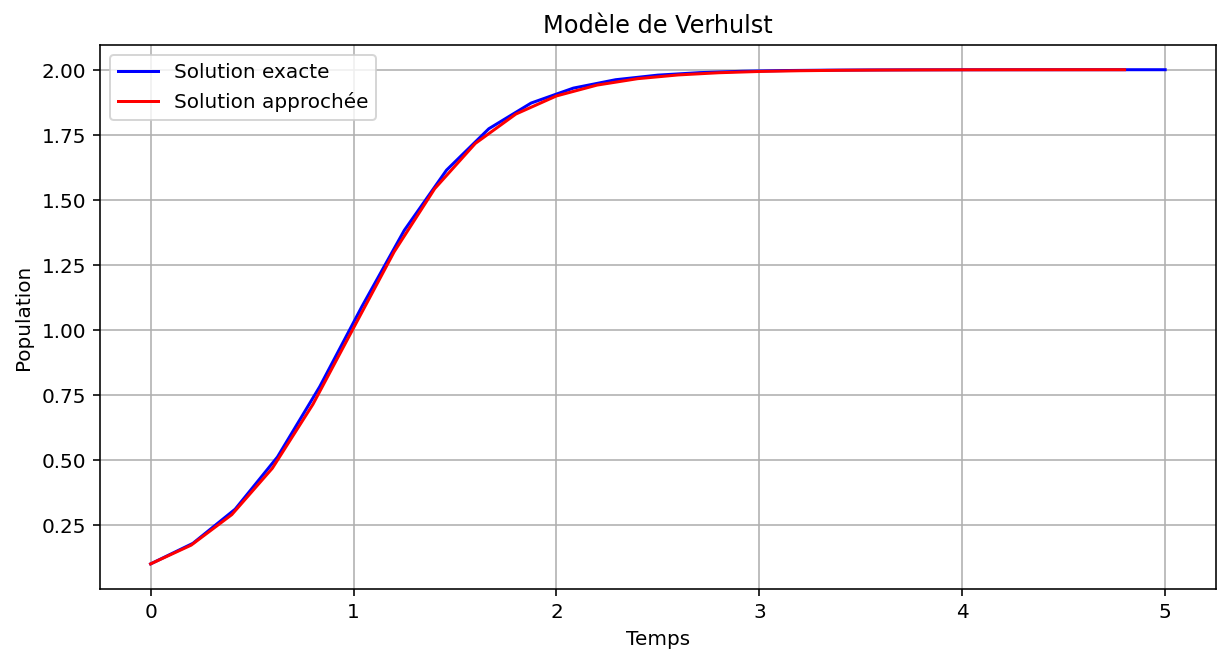

In [11]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)
ax.set_title("Modèle de Verhulst")
ax.set_xlabel("Temps")
ax.set_ylabel("Population")
ax.grid(True)
N = 25
t0, tf = 0, 5
t = np.linspace(t0, tf, N)
y = x(t)
ax.plot(t, y, label="Solution exacte", color='blue')
t, y = monSchemaExplicite(f, t0, tf, x0, N, monPasPointMilieu)
ax.plot(t, y, label="Solution approchée", color='red')
ax.legend()
plt.show()


### Question II-2 : Validations ( Schémas de Heun))

On consière ici le schéma de Heun :

\begin{equation}
(Heun)\quad \left\{
\begin{array}{rcl}
t_{n+1} &=& t_{n} + \Delta t \\
x_{n+1}^* &=& x_n + \Delta t \, f(t_n, x_n) \\
x_{n+1}   &=& x_n + \frac{\Delta t}{2} \,\Big( f(t_{n}, x_{n}) + f(t_{n + 1}, x_{n+1}^* ) \Big), \quad n = 0,\ldots, N-1,\\
x_0 &=& x^0.
\end{array}
\right.
\end{equation}
ou de manière équivanlente :
\begin{equation}
(Heun)\quad \left\{
\begin{array}{rcl}
x_{n+1}  &=& x_n + \frac{\Delta t}{2} \,\Big(f(t_n, x_n) + f\big(t_{n+1}, x_n + \Delta t\, f(t_n, x_n)\big) \Big), \quad n = 0,\ldots, N-1,\\
x_0 &=& x^0.
\end{array}
\right.
\end{equation}


>1. Proposer à l'image de `monPasEuler`  une fonction `monPasHeun(f, tn, xn, dt)` 
mettant en oeuvre ce schéma.

In [12]:
def monPasHz(f,tn,xn,dt):
    tn += dt
    xn += dt/2 * (f(tn,xn) + f(tn+dt,xn + dt * f(tn, xn)))
    return tn,xn,dt

>2. En vous servant de la fonction `monSchemaExplicite` et de la fonction `monPasHeun`
reprendre l'expérience de la question **Question I-3** pour ce schéma. 

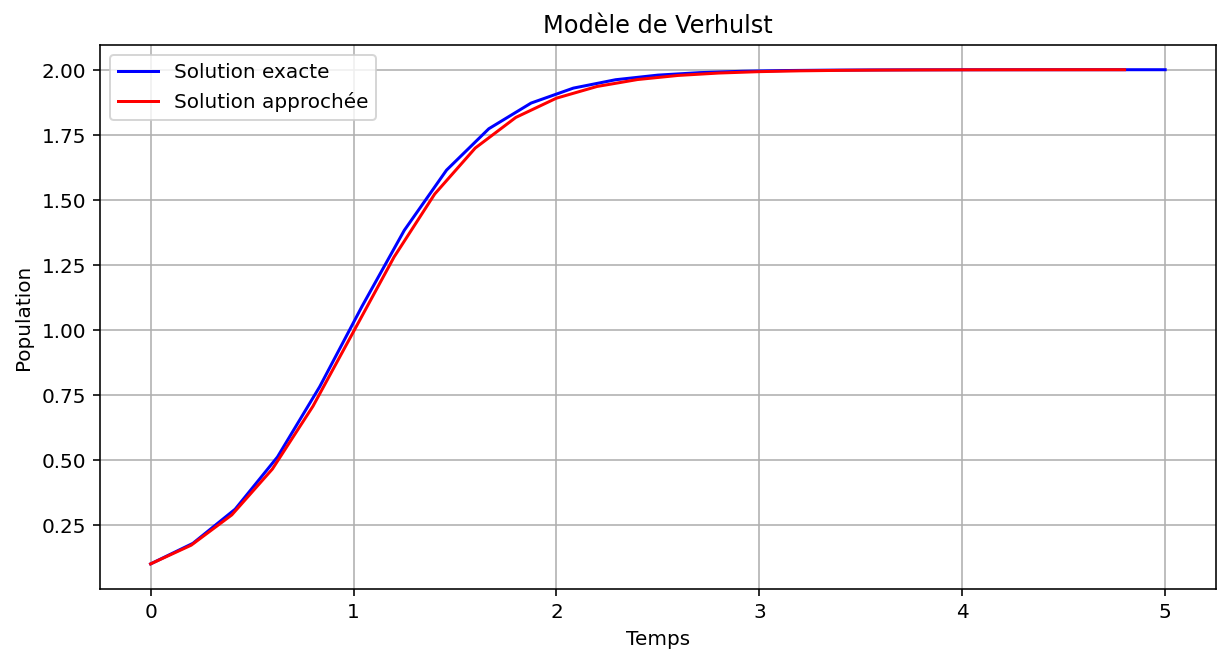

In [13]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)
ax.set_title("Modèle de Verhulst")
ax.set_xlabel("Temps")
ax.set_ylabel("Population")
ax.grid(True)
N = 25
t0, tf = 0, 5
t = np.linspace(t0, tf, N)
y = x(t)
ax.plot(t, y, label="Solution exacte", color='blue')
t, y = monSchemaExplicite(f, t0, tf, x0, N, monPasHz)
ax.plot(t, y, label="Solution approchée", color='red')
ax.legend()
plt.show()


---
## Partie III : Convergence et ordre de convergence
---

### Question III-1: Convergence du schéma ( cas, d'Euler explcite)

>1. En consiudérant le modèle de Verhulst ci-dessus, et pour $N = 2^{1}, 2^{4}, \ldots, 2^{8}$
tracer sur une même figure la solution exacte et les solutions approchées obtenues. Chaque solution approchée sera identifiée 
sur la figure par son label correspondant au pas $\Delta t$ de la subdivision utilisé.
>2. Quelle obervation faites-vous lors que $\Delta t \rightarrow 0$.

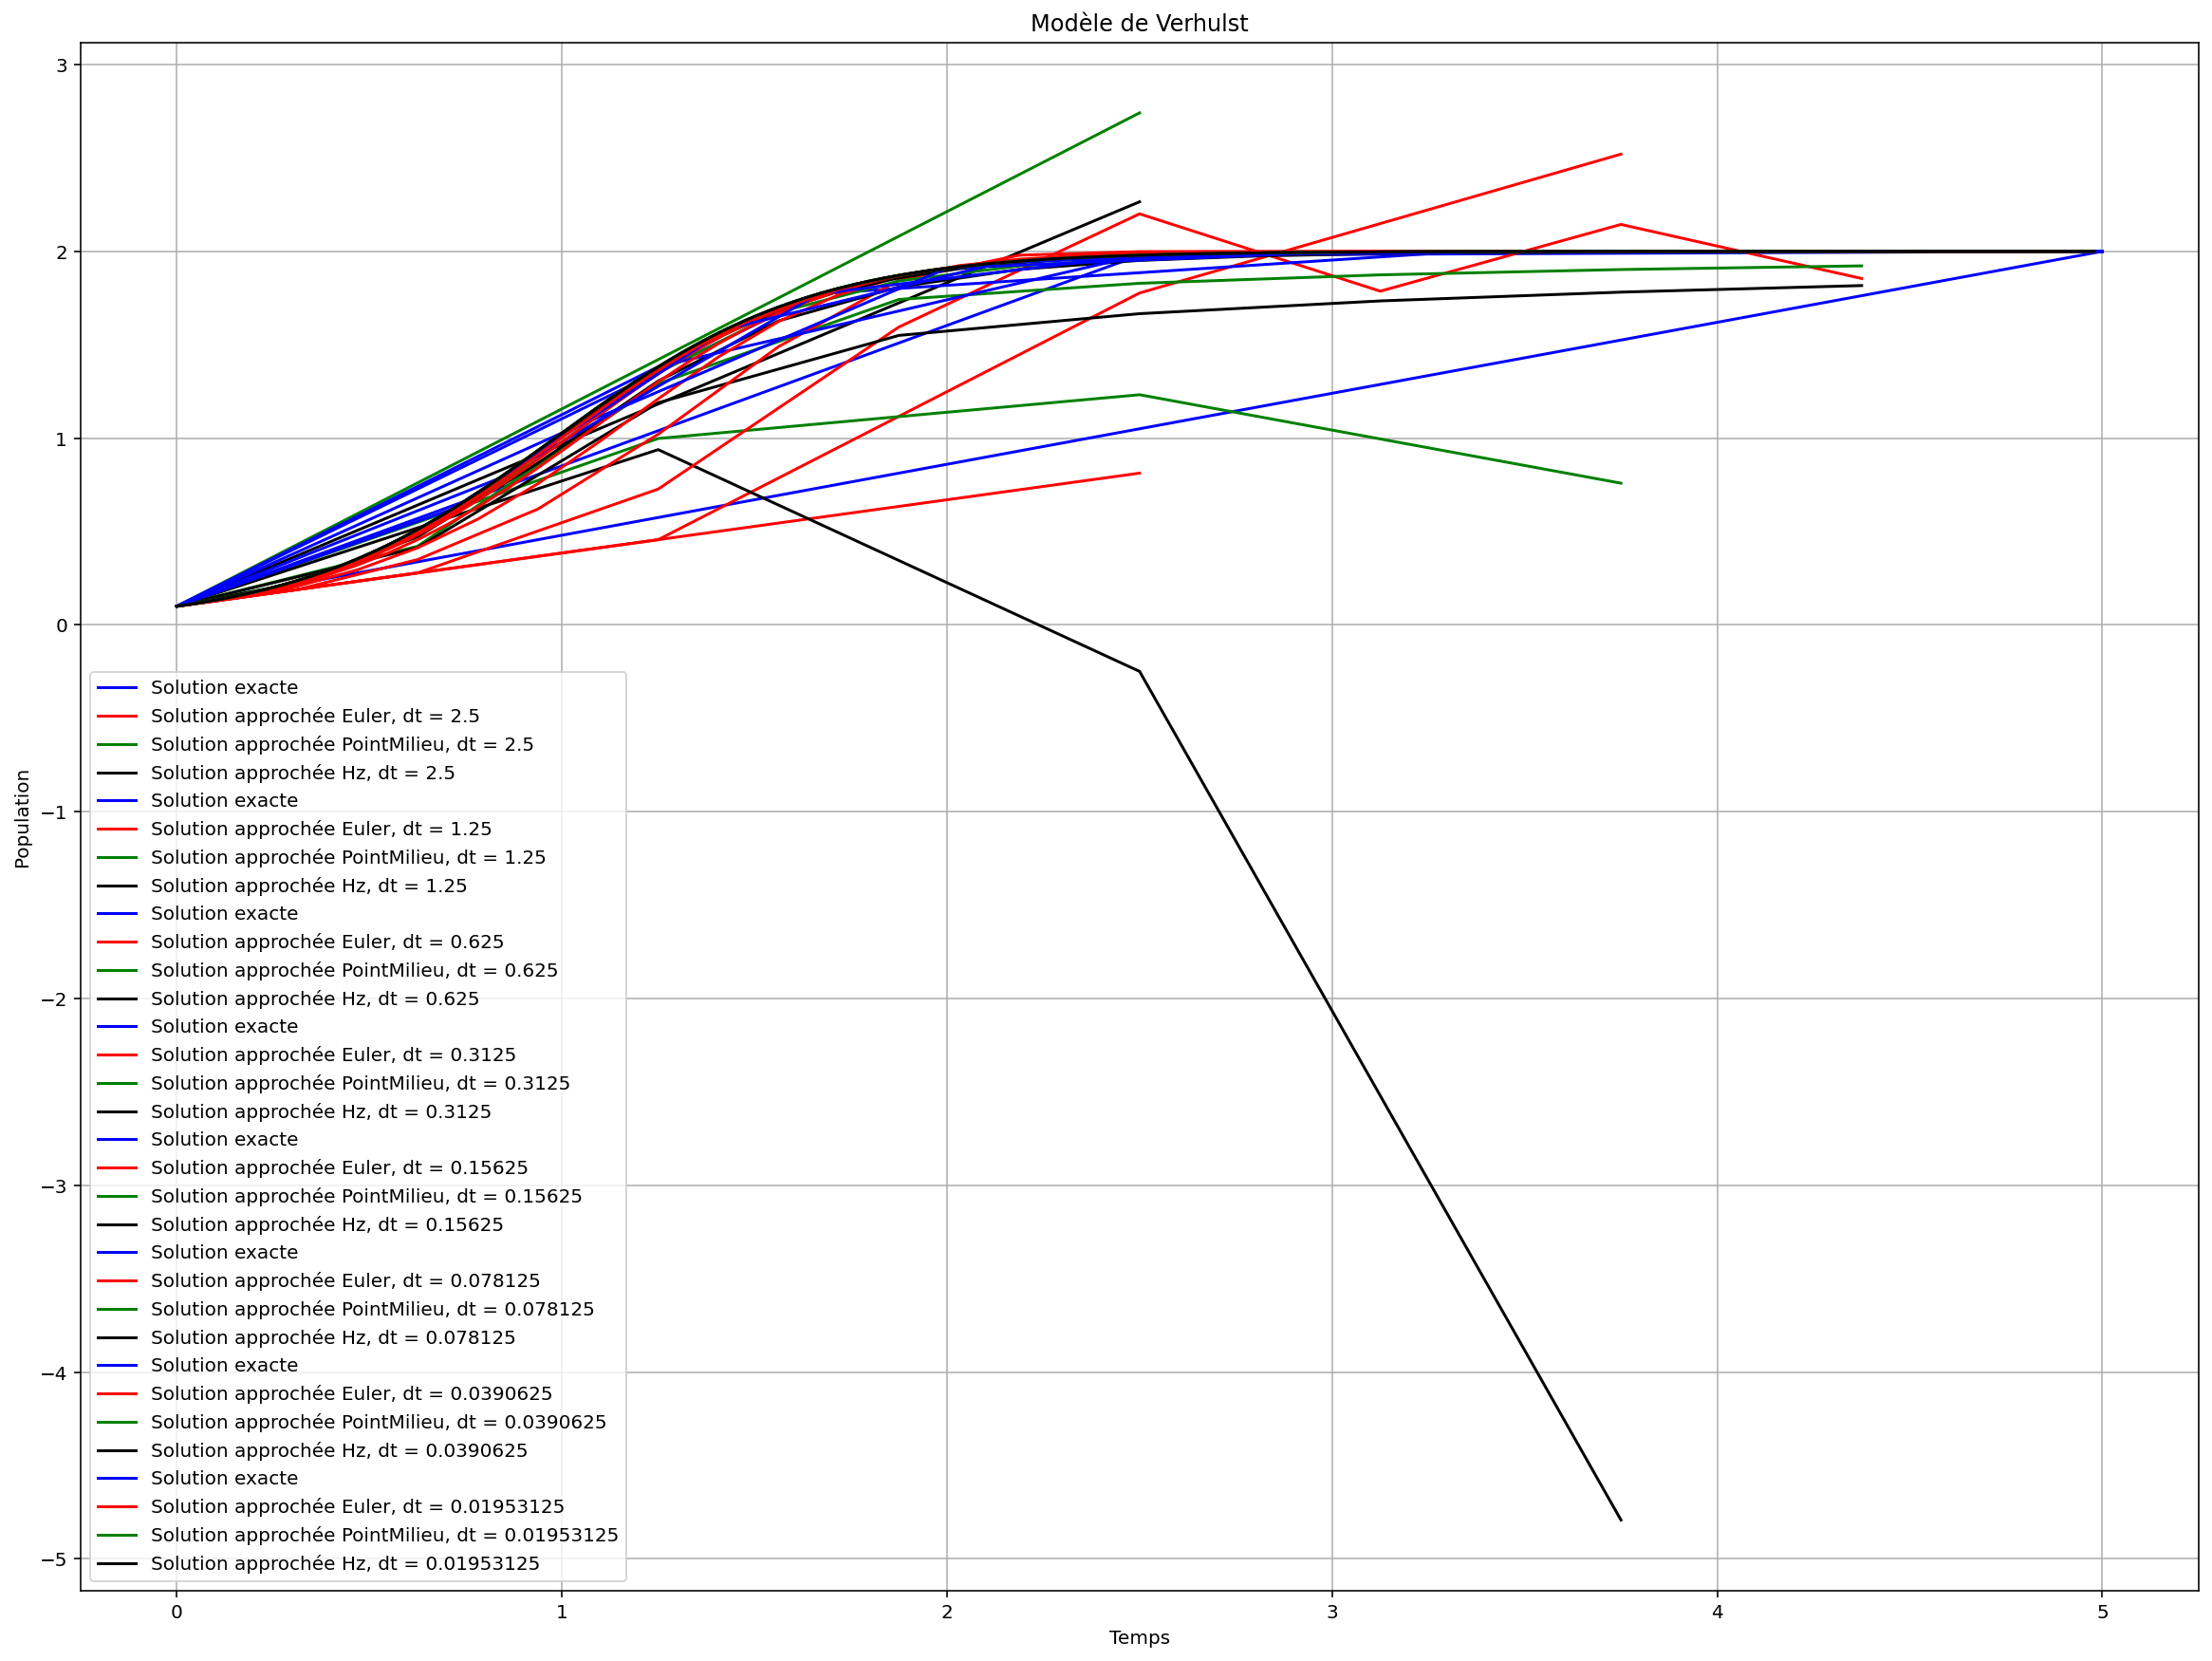

In [22]:
fig = plt.figure(figsize=(20, 15))
ax = fig.add_subplot(111)
ax.set_title("Modèle de Verhulst")
ax.set_xlabel("Temps")
ax.set_ylabel("Population")
ax.grid(True)
N = 2
t0, tf = 0, 5
for i in range(1,9):
    t = np.linspace(t0, tf,i)
    y = x(t)
    ax.plot(t, y, label="Solution exacte", color='blue')
    t, y = monSchemaExplicite(f, t0, tf, x0, N**i, monPasEuler)
    ax.plot(t, y, label=f"Solution approchée Euler, dt = {(tf-t0)/N**i}", color='red')
    t, y = monSchemaExplicite(f, t0, tf, x0, N**i, monPasPointMilieu)
    ax.plot(t, y, label=f"Solution approchée PointMilieu, dt = {(tf-t0)/N**i}", color='green')
    t, y = monSchemaExplicite(f, t0, tf, x0, N**i, monPasHz)
    ax.plot(t, y, label=f"Solution approchée Hz, dt = {(tf-t0)/N**i}", color='black')
ax.legend()
plt.show()


### Question III-1: Fonction d'analyse de l'ordre
En vous inspirant de ce qui a été fait dans l'exercice sur l'intégration numérique 
(voir **Question I-1**  du **TP08**, et sa fonction  `analyse_erreur(f,a,b,meth,title)`),

proposez ici une fonction `analyse_erreur_schema_un_pas(f, t0, tf, x_exacte, monPasSchema, title)` qui prend en argument une fonction `f` second membre de l'EDO, l'instant initial `t0` et final `tf`, la fonction solution exacte `x_exacte` (`x_exacte(t)` est la solution exacte à l'instant `t`), le schéma à un pas `monPasSchéma` 
    et une chaîne de caractères `title` et qui estime l'ordre de convergence du schéma explicite à un pas ustilisé pour la résolution de l'EDO.  Pour cela, cette fonction observera l'évolution de l'erreur $E_{\Delta t}$ en fonction du pas $\Delta t$ pour les valeurs de $N = 2^{3}, 2^{4}, \ldots, 2^{10}$. 


In [19]:
def analyse_erreur_schema_un_pas(f, t0, tf, x_exacte, monPasSchema, title):
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(111)
    ax.set_title(title)
    ax.set_xlabel("Pas de temps")
    ax.set_ylabel("Erreur")
    ax.grid(True)
    N = 2
    t0, tf = 0, 5
    for i in range(3,11):
        t = np.linspace(t0, tf, N**i)
        y = x_exacte(t)
        t, y = monSchemaExplicite(f, t0, tf, x0, N**i, monPasSchema)
        ax.plot((tf-t0)/N**i, np.abs(y-x_exacte(t)), label=f"Erreur, dt = {(tf-t0)/N**i}")
    ax.legend()
    plt.show()

### Question III-2: Estimation d'ordre  de convergence ( cas Euler, Point-Milieu, Heun) 

En utilisant la fonction `analyse_erreur_schema_un_pas` ci-dessus, et en utilisant le modèle de Verhulst 
(**Question I-3**  ci-dessus )

>- Estimer l'ordre de convergence du schéma d'Euler Explcite
>- Estimer l'ordre de convergence du schéma du Point-Milieu
>- Estimer l'ordre de convergence du schéma de Heun.


ValueError: operands could not be broadcast together with shapes (8,) (0,) 

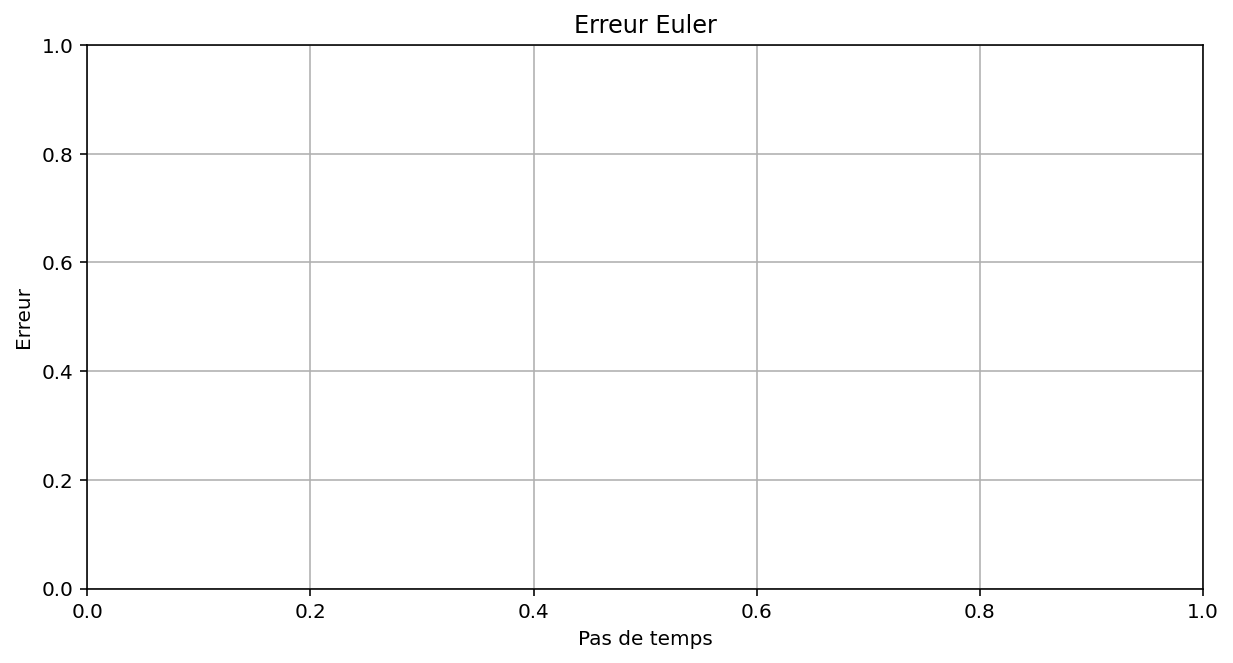

In [20]:
analyse_erreur_schema_un_pas(f, t0, tf, x, monPasEuler, "Erreur Euler")
analyse_erreur_schema_un_pas(f, t0, tf, x, monPasPointMilieu, "Erreur Point Milieu")
analyse_erreur_schema_un_pas(f, t0, tf, x, monPasHz, "Erreur Heun")

---
## Partie IV  : Comparaisons  : Importance de l'ordre de précision
---

On considère le problème  (EDO) avec On considère ici le problème (EDO) ci-dessus avec $f(t, y) = \frac{3 y}{t} - \frac{5}{t^3}$ 
qu'on résout sur l'intervalle $[1, 5]$ avec une donnée initiale $x(1) = 1$.

>1. Vérifiez que la solution exacte est $x(t) = \frac{1}{t^2}, \quad t \in [1,5]$ 
>2. Pour $N = 100$ représentez sur le même graphique la solution exacte et les solutions approchées obtenues par les schémas d'Euler explcite et de Heun, et du Point Milieu
>3. Que remarquez-vous ? 


In [6]:
t0, tf, N, x0 = 1., 5., 100, 1.


---
## Partie V  : Comparaisons: schémas explicites vs implicites sur cas explicitables
---

On considère ici à nouveau le problème (EDO) ci-dessus avec $f(t, y) = \frac{3 y}{t} - \frac{5}{t^3}$ 
qu'on résout sur l'intervalle $[1, 5]$ avec une donnée initiale $x(1) = 1$.

### Question V-1: Solution exacte.
>1- Vérifiez que la solution exacte est $x(t) = \frac{1}{t^2}, \quad t \in [1,5]$ 


### Question V-2: Schémas implcites et leur explicitabilité dans ce contexte

On considère les 4 schémas suivants: les schémas d'Euler explicite et de Heun ci-dessus, et les schémas 
d'Euler implicite et du de Crank-Nicolson ci-dessous:

>- Euler implicite :
\begin{equation}
(EI)\quad \left\{
\begin{array}{rcl}
x_{n+1}  &=& x_n + \Delta t\,f(t_{n+1}, x_{n+1}), \quad n = 0,\ldots, N-1,\\
x_0 &=& x^0.
\end{array}
\right.
\end{equation}

>- CranK-Nicolson 
\begin{equation}
(CN)\quad \left\{
\begin{array}{rcl}
x_{n+1}  &=& x_n + \frac{\Delta t}{2} \,\Big(f(t_n, x_n) + f\big(t_{n+1}, x_{n+1} \big) \Big), \quad n = 0,\ldots, N-1,\\
x_0 &=& x^0.
\end{array}
\right.
\end{equation}

#### Question IV-2-1: Explicitabilité

> Montrer que les schémas (EI) et (CN) ci-dessus sont implicites, mais pour le problème considéré, on peut exprimer $x_{n+1}$ en fonction de $x_{n}$ (C'est-à-dire que pour ce problème ces schémas implicites sont explcitables).

#### Question IV-2-2: Comparaisons 

> Pour $N = 100$, créez trois figures :
>>- dans l'une représentez la solution exacte et les solutions approchées par le schéma d'Euler explicite
et le schéma de Heun
>>- Dans l'autre représentez la solution exacte et les solutions approchées par les schémas d'Euler explicite et 
implicite
>>- Dans le dernier représentez la solution solution exacte et les solutions approchées par le schéma 
de Heun et le schéma de Crank-Nicholson.

>3- Commentez les résultats observés.

>**RQ**: commme cette partie dépend explcitement de la fonction $f$, on peut donc si on le veut, 
fournir des fonctions qui construisent les solutions :
`EulerExpliciteAutreCas(t0, tf, N, x0)`, `HeunAutreCas(t0, tf, N, x0)`, `EulerImpliciteAutreCas(t0, tf, N, x0)`
`CrankNicolsonAutreCas(t0, tf, N, x0)`.
Ainsi que la solution exacte `solExacteAutreCas(t)`.


In [8]:
def f(t,y):
    ...
    

### Question V-3: Autre example:
Essayez de reprendre les questions ci-dessus avec le problème (EDO) où $f(t, y) = \frac{\cos(t) - y}{t+1}$ 
sur l'intervalle $[0, 10]$ avec une donné initiale $x^0 = -\frac14$, pour lequel la solution exacte est 
$x(t) = \frac{\sin(t) - \frac14}{t + 1}, \quad  t\in[0, 10]$


---
## Partie VI : Observation quantifiable de l'erreur globale par itération 
---
Pour la plupart des  EDO, on ne dispose pas de la solution exacte. On aimerait cependant avoir une estimation de l'erreur que l'on commet à chaque itération. On parle alors d'estimation à postériori de l'erreur. 
(*Ceci est le chemin emprunté par les techniques d'adaptation de pas, visant à concentrer plus de points là où la solution exacte présente des maximas*).

On va supposer que l'on  dispose des dérivées partielles premières de $f$. 
On pose $\displaystyle f_t (t, y) =\frac{\partial f}{\partial t} (t,y), \quad  f_y (t, y) = \frac{\partial f}{\partial y} (t,y) $

On va s'interesser au schéma d'Euler explicite. 

\begin{equation}
(EE)\quad \left\{
\begin{array}{rcl}
x_{n+1}  &=& x_n + \Delta t \,f(t_n, x_n), \quad n = 0,\ldots, N-1,\\
x_0 &=& x^0.
\end{array}
\right.
\end{equation}

On associe à ce schéma le schéma suivant : 
\begin{equation}
(Erreur)\quad \left\{
\begin{array}{rcl}
e_{n+1}  &=& e_n + \Delta t \,f_y(t_n, x_n) e_n + \frac{\Delta t}{2} \Big( f_t(t_n, x_n) + f(t_n, x_n) f_y(t_n, x_n) \Big)  , \quad n = 0,\ldots, N-1,\\
e_0 &=& 0.
\end{array}
\right.
\end{equation}

Ce qui nous donne le schéma suivant qui construit les suites $(x_n)$ et $(e_n)$ simultanément:

\begin{equation}
(EEC)\quad \left\{
\begin{array}{rcl}
x_0 &=& x^0 \\
e_0 &=& 0, \\
x_{n+1}  &=& x_n + \Delta t \,f(t_n, x_n), \\ 
e_{n+1}  &=& e_n + \Delta t \,f_y(t_n, x_n) e_n + \frac{\Delta t}{2}\,  \Big( f_t(t_n, x_n) + f(t_n, x_n) f_y(t_n, x_n) \Big)  , \quad n 
= 0,\ldots, N-1,
\end{array}
\right.
\end{equation}





### Question VI-1: Préparations
>1. Donnez l'expression de $f(t,y), f_t(t,y)$ et $f_y(t,y)$ dans le model de Verhulst de la **Question I-3** 
>2. Programmer ces expression à travers les fonctions `f_verhulst(t,y)`,  `ft_verhulst(t,y)` et `fy_verhulst(t,y)`. On définir aussi la solution exacte du modèle de Verhulst via `sol_verhulst(t)`.

In [7]:
r, K, x0 = 3, 2, 0.1

def f_verhulst(t,y):
    """ """
    ...

def ft_verhulst(t, y):
    """ """
    ...

def fy_verhulst(t,y):
    """ """
    ...

def sol_verhulst(t):
    ...

### Question VI-2: Calculs

Pour $t_0 = 0, T = 5, N = 100$ 
>1. Caluler la suite des instants $(t_n)$, et les suites $(x_n)$, $(e_n)$ construites par la schéma (EEC).
>2. Afficher $t_n$, $|x(t_n) - x_n|$ et $|e_n \times \Delta t|$ selon le format :
```
------------------------------------------------------------
        tn             |x(tn) - xn|                   en * dt
------------------------------------------------------------
0.000000000      0.0000000000000E+00      0.0000000000000E+00
0.050000000      1.0008475906470E-03      9.6187500000000E-04
0.100000000      2.2566564182071E-03      2.1631028196973E-03
0.150000000      3.8035781713976E-03      3.6378433377296E-03
0.200000000      5.6773987992150E-03      5.4205786042207E-03
0.250000000      7.9114246166046E-03      7.5444603089643E-03
0.300000000      1.0533707695700E-02      1.0039093216278E-02
...
5.000000000      6.1463146667773E-06      4.2902584058267E-06
------------------------------------------------------------
 ```